<a href="https://colab.research.google.com/github/Rithanya77-05/rithanya-codebooster-2026/blob/main/Day-3/mini_day3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [16]:
API_KEY ='74a4b330a7f4bf6743f688a910b6675d'
BASE_URL='https://api.openweathermap.org/data/2.5/weather'
CITIES =['Mumbai','Delhi','Bangalore','Chennai','Hyderabad','Coimbatore', 'Pune','Jaipur']
print(f'API configured for {len(CITIES)} cities')
print(f'Cities:{CITIES}')

API configured for 8 cities
Cities:['Mumbai', 'Delhi', 'Bangalore', 'Chennai', 'Hyderabad', 'Coimbatore', 'Pune', 'Jaipur']


In [17]:
import requests

def fetch_weather(city, api_key):
  """
  Fetch current weather data for a given city.
  Returns a dictionary with weather metrics, or None on failure.
  """

  params = {
      'q': city,
      'appid': api_key,
      'units': 'metric'
  }

  try:
    response = requests.get(BASE_URL, params=params, timeout=10)

    if response.status_code == 200:
      data = response.json()

      return {
          'city': city,
          'temperature': round(data['main']['temp'], 1),
          'feels_like': round(data['main']['feels_like'], 1),
          'humidity': data['main']['humidity'],
          'pressure': data['main']['pressure'],
          'wind_speed': data['wind']['speed'],
          'condition': data['weather'][0]['description'],
          'visibility': data['visibility']
      }
    else:
      print(f'ERROR {response.status_code} for {city}:{response.json().get("message")}')
      return None
  except requests.exceptions.RequestException as e:
    print(f'Request failed for {city}: {e}')
    return None


weather_records = []
print('Calling Weather API....')
for city in CITIES:
  print(f'Fetching: {city}...', end='')
  record = fetch_weather(city, API_KEY)
  if record:
    weather_records.append(record)
    print(f'{record["temperature"]}°C')
  else:
    print('Failed')

import pandas as pd
df_weather = pd.DataFrame(weather_records)
display(df_weather.head())

Calling Weather API....
Fetching: Mumbai...34.0°C
Fetching: Delhi...44.0°C
Fetching: Bangalore...29.4°C
Fetching: Chennai...35.9°C
Fetching: Hyderabad...31.2°C
Fetching: Coimbatore...33.9°C
Fetching: Pune...36.3°C
Fetching: Jaipur...42.6°C


,city,temperature,feels_like,humidity,pressure,wind_speed,condition,visibility
0,Mumbai,34.0,41.0,59,1009,6.17,haze,7000
1,Delhi,44.0,41.1,10,999,5.14,clear sky,7000
2,Bangalore,29.4,31.1,56,1009,4.63,scattered clouds,8000
3,Chennai,35.9,42.9,53,1005,5.14,few clouds,6000
4,Hyderabad,31.2,33.2,51,1008,8.75,broken clouds,6000


In [18]:
df_weather_json = df_weather.to_json(orient='records', indent=4)
print(df_weather_json)

[
    {
        "city":"Mumbai",
        "temperature":34.0,
        "feels_like":41.0,
        "humidity":59,
        "pressure":1009,
        "wind_speed":6.17,
        "condition":"haze",
        "visibility":7000
    },
    {
        "city":"Delhi",
        "temperature":44.0,
        "feels_like":41.1,
        "humidity":10,
        "pressure":999,
        "wind_speed":5.14,
        "condition":"clear sky",
        "visibility":7000
    },
    {
        "city":"Bangalore",
        "temperature":29.4,
        "feels_like":31.1,
        "humidity":56,
        "pressure":1009,
        "wind_speed":4.63,
        "condition":"scattered clouds",
        "visibility":8000
    },
    {
        "city":"Chennai",
        "temperature":35.9,
        "feels_like":42.9,
        "humidity":53,
        "pressure":1005,
        "wind_speed":5.14,
        "condition":"few clouds",
        "visibility":6000
    },
    {
        "city":"Hyderabad",
        "temperature":31.2,
        "feels_like":33

In [21]:
import json

records = df_weather.to_dict(orient='records')
formatted_records = [json.dumps(record, indent=None) for record in records]
output_json_per_line = """[
""" + ",\n".join(formatted_records) + """\n]"""

print(output_json_per_line)

[
{"city": "Mumbai", "temperature": 34.0, "feels_like": 41.0, "humidity": 59, "pressure": 1009, "wind_speed": 6.17, "condition": "haze", "visibility": 7000},
{"city": "Delhi", "temperature": 44.0, "feels_like": 41.1, "humidity": 10, "pressure": 999, "wind_speed": 5.14, "condition": "clear sky", "visibility": 7000},
{"city": "Bangalore", "temperature": 29.4, "feels_like": 31.1, "humidity": 56, "pressure": 1009, "wind_speed": 4.63, "condition": "scattered clouds", "visibility": 8000},
{"city": "Chennai", "temperature": 35.9, "feels_like": 42.9, "humidity": 53, "pressure": 1005, "wind_speed": 5.14, "condition": "few clouds", "visibility": 6000},
{"city": "Hyderabad", "temperature": 31.2, "feels_like": 33.2, "humidity": 51, "pressure": 1008, "wind_speed": 8.75, "condition": "broken clouds", "visibility": 6000},
{"city": "Coimbatore", "temperature": 33.9, "feels_like": 38.8, "humidity": 52, "pressure": 1008, "wind_speed": 4.12, "condition": "scattered clouds", "visibility": 7000},
{"city": 

In [23]:
weather_df=pd.DataFrame(weather_records)
print('WEather DataFrame created:')
print(weather_df.to_string(index=False))
print(f"\n Shape:{weather_df.shape}")
print(f"Missing values: {weather_df.isnull().sum().sum()}")
print(f'\nData Types:')
print(weather_df.dtypes)



WEather DataFrame created:
      city  temperature  feels_like  humidity  pressure  wind_speed        condition  visibility
    Mumbai         34.0        41.0        59      1009        6.17             haze        7000
     Delhi         44.0        41.1        10       999        5.14        clear sky        7000
 Bangalore         29.4        31.1        56      1009        4.63 scattered clouds        8000
   Chennai         35.9        42.9        53      1005        5.14       few clouds        6000
 Hyderabad         31.2        33.2        51      1008        8.75    broken clouds        6000
Coimbatore         33.9        38.8        52      1008        4.12 scattered clouds        7000
      Pune         36.3        36.0        27      1008        3.76  overcast clouds       10000
    Jaipur         42.6        41.3        15      1001        5.14             haze        5000

 Shape:(8, 8)
Missing values: 0

Data Types:
city            object
temperature    float64
feels_li

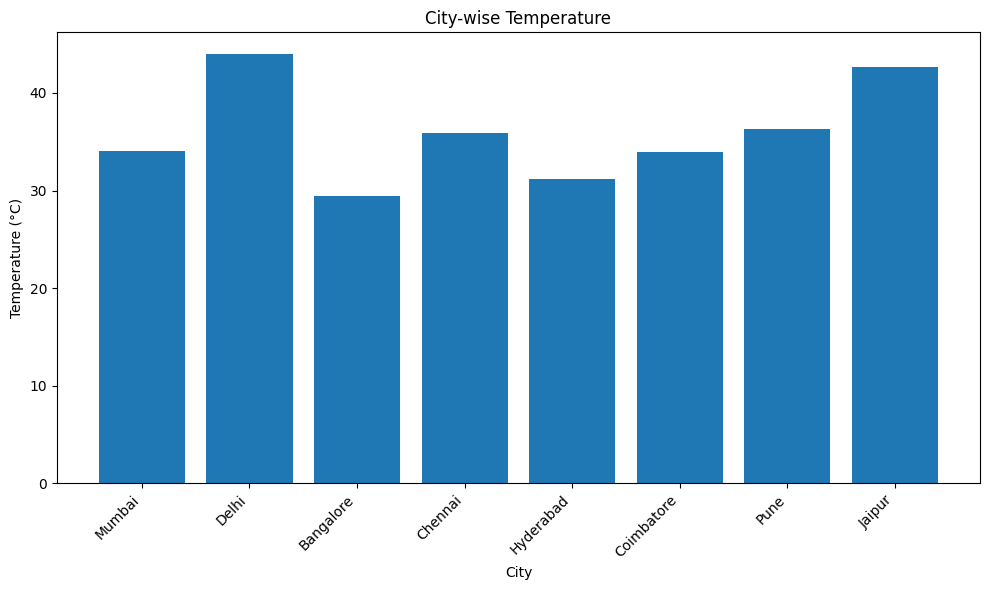

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import requests
plt.figure(figsize=(10,6))
plt.bar(weather_df['city'],weather_df['temperature'])
plt.title('City-wise Temperature')
plt.xlabel('City')
plt.ylabel('Temperature (°C)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()